# Software profesional en Acústica 2025-26 (M2i)

*This notebook contains a modification of the notebook [ElasticBarLinearFEM](https://github.com/garth-wells/notebooks-3D7), used in the course **3D7 Finite Element Methods** in the University of Cambridge, and created by Garth N. Wells. The code is released under the [MIT license](https://opensource.org/licenses/MIT).*

First, we need to install on the fly [NGSolve](https://ngsolve.org/) using the [FEM on Colab](https://fem-on-colab.github.io/packages.html) install script:

In [1]:
try:
    import ngsolve
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/ngsolve-install-release-complex.sh" -O "/tmp/ngsolve-install.sh" && bash "/tmp/ngsolve-install.sh"
    import ngsolve

# Finite element method

We create in this notebook a simple finite element solver for the Helmholtz equation with piecewise linear finite elements. We will use **NGSolve** to perform the simulations, and **Matplotlib** to visualise the results, so we first import the **NumPy** and **Matplotlib** and **NGSolve** modules:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# import ngsolve
from ngsolve import *
from ngsolve.meshes import Make1DMesh
import ipywidgets as widgets

# Setting matplotlib to display plots inline in the notebook
%matplotlib inline

## Statement of the problem

Solve the Helmholtz problem using the finite element method, and plot the numerical approximation. The ODE is
$$ -\frac{d^2u}{dx^2} - k^2u = f,\qquad k=\frac{\omega}{c},$$
with the boundary conditions $u(0) = 0$ and $u(\pi) = 0$ and source term $f(x)=1$. Let's take $n=10$.

### Wavenumber and Source term
We now define the source term $f$. We will use a function that takes the coordinate $x$ as an argument so we possibly define loading terms that vary with position.

In [3]:
k = 1.5  # wavenumber
distributed_load = 1.0  # constant source term f(x) = 1

### Mesh
We will create a mesh of length $L$ with a prescribed number of cells (elements) $n_{\text{cells}}$. For linear elements, the number of nodes is equal to $n_{\text{cells}} + 1$.

In [4]:
L = np.pi
n_cells = 10

To create a mesh from 0 to $L$ with equal size cells (elements) we will use NGSolve's `Mesh` to generate a mesh of equally spaced points on the interval $[0, L]$.

In [5]:
mesh = Make1DMesh(n_cells, mapping = lambda x : L*x)

Matplotlib can be used to visualise the mesh:

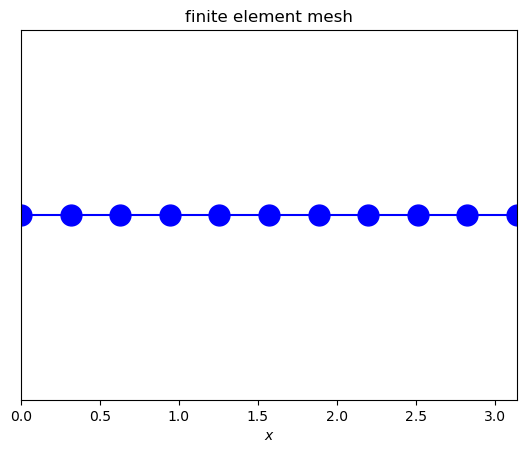

In [6]:
# Extract node coordinates for plotting
coords = sorted([v.point[0] for v in mesh.vertices])
plt.xlabel('$x$')
plt.title('finite element mesh')
plt.plot(coords, np.zeros_like(coords), 'bo-', markersize=15)
plt.yticks([])
plt.xlim(0., L)
plt.show()

### A simple finite element solver

We have already defined our domain (the mesh) and the wavenumber $k$. We now need to build the global stiffness and mass matrix $K$ and $M$, respectively, and the global right-hand side vector $\vec{b}$, after which we can solve $(K-k^2M) \vec{u} = \vec{b}$ to get the nodal degrees-of-freedom $\vec{u}$.

With this aim, the first step is the definition of the finite element discrete space (in this case Continuos Galerkin $\mathbb{P}^1$ elements, this is, piecewise linear Lagrange finite elements), and assign test and trial functions to write the corresponding variational formulations of the stiffness and mass terms.

In [7]:
# Define the function space: Continuous Galerkin (H1), order=1
V = H1(mesh, order=1, dirichlet="left|right", complex=True)

# Define the test and trial functions
u = V.TrialFunction()
v = V.TestFunction()

#### Define the variational formulation for the stiffness term $\boldsymbol{K}$

We define the variational formulation of the stiffness term

In [8]:
A_form = BilinearForm(V)
A_form += grad(u) * grad(v) * dx

#### Define the variational formulation for the mass term $\boldsymbol{M}$

We define the variational formulation of the mass term

In [9]:
A_form += -k**2 * u * v * dx

##### Assemble global (and sparse) stiffness and mass matrices

To build the global stiffness and mass matrices $K$ and $M$, we first create an empty $n_{\text{nodes}} \times n_{\text{nodes}}$ matrix:

In [10]:
A_form.Assemble()

#### Create RHS vector $\boldsymbol{b}$

We create the global RHS vector $\vec{b}$ by computing the cell RHS $\vec{b}_{e}$ cell-by-cell, and adding this to the global RHS vector. We allow the distributed load $f$ to vary with position, which is why we cannot compute it just once. For simplicity we will integrate the local RHS using the midpoint rule. This is exact if $f$ is constant, and is otherwise approximate.

We first create an empty global RHS vector:

In [11]:
b_form = LinearForm(V)
b_form += distributed_load * v * dx
b_form.Assemble()

We now loop over each cell and compute $\int_{x_{i}}^{x_{i+1}} N_{1} f dx=\frac{h}{2}f(x_{i+\frac12})$ and $\int_{x_{i}}^{x_{i+1}} N_{2} f dx=\frac{h}{2}f(x_{i+\frac12})$ for each cell, and add the contribution to the global RHS vector:

#### Apply Dirichet (displacement) boundary condition

We're almost ready to solve a finite element problem, but we would get into trouble if we tried to solve $A \vec{u} = \vec{b}$ using the above stiffness matrix because it is singular (you can verify this by computing its determinant). The system is singular because we have not applied a Dirichlet boundary condition, and hence multiple solutions are possible.

We impose the boundary condition $u = 0$ and $x=0$ by zeroing the first row and column of the matrix, placing a one on the first diagonal entry and setting the first entry on the RHS to zero. It should be clear algebraically that this will ensure that the first degree of freedom is equal to zero when we solve the system.

In [12]:
# Define the solution vector
gfu = GridFunction(V)

# Set Dirichlet boundary conditions (u=0 on left and right boundaries)
uD = CF(0.0)
gfu.Set(uD, definedon=mesh.Boundaries("left|right"))

#### Solve system of equations

We can now solve the finite element system:

In [13]:
# Sparse direct solver
solver = Preconditioner(A_form,"direct")

# Solve the acoustic problem at t=0
solvers.BVP(bf=A_form, lf=b_form, gf=gfu, pre=solver, print=False)

#### Visualising the solution

We now plot the solution:

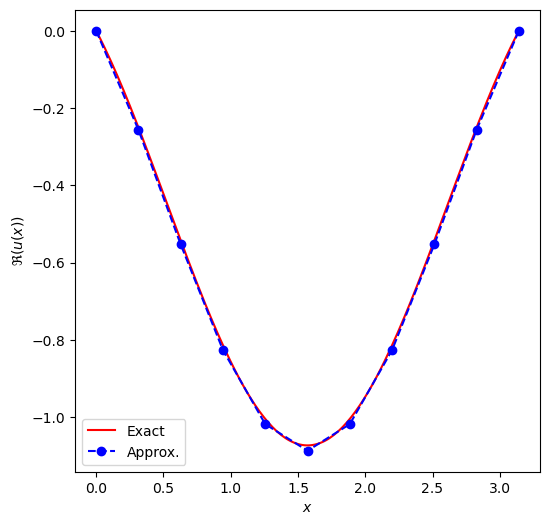

In [14]:
# Plot the solution
plt.figure(figsize=(6, 6))

# Grid for plotting the exact solution
x_grid = np.linspace(0, L, 200)

# Exact solution
u_exact = (np.cos(k * (x_grid - np.pi / 2)) / np.cos(k * np.pi / 2) - 1) / k**2

# Approximated solution
x_mesh = np.array([v.point[0] for v in mesh.vertices])
u_h = np.array([gfu(mesh(v.point[0])) for v in mesh.vertices])

# Plotting both the numerical and exact solutions
plt.plot(x_grid, u_exact.real, 'r-', label='Exact')
plt.plot(x_mesh, u_h.real, 'bo--', label='Approx.')
plt.xlabel(r'$x$')
plt.ylabel(r'$\Re(u(x))$')
plt.legend()
plt.show()

## A more programmatic approach

We now present a finite element solver that is very similar the one above, but we now provide a programming interface so we can reuse a function to explore different loading functions and different levels of refinement of the mesh.

In [15]:
def compute_fem(L, k, f_source, uD, n_cells):
    """Compute the FEM solution for the Helmholtz equation on [0, L].

    Parameters
    ----------
    L           : float, domain length
    k           : float, wavenumber
    f_source    : float or NGSolve CoefficientFunction, source term
    uD          : float or NGSolve CoefficientFunction, Dirichlet BC value
    n_cells     : int, number of elements

    Returns
    -------
    sol  : GridFunction with the solution
    mesh : NGSolve Mesh
    V    : H1 FESpace
    """
    # Create mesh and function space
    mesh = Make1DMesh(n_cells, mapping = lambda x : L*x)
    V = H1(mesh, order=1, dirichlet="left|right", complex=True)
    u = V.TrialFunction()
    v = V.TestFunction()

    # Variational forms
    A_form = BilinearForm(V)
    A_form += grad(u) * grad(v) * dx
    A_form += -k**2 * u * v * dx
    b_form = LinearForm(V)
    b_form += f_source * v * dx

    # Assemble forms
    A_form.Assemble()
    b_form.Assemble()

    # Define the solution vector
    gfu = GridFunction(V)

    # Set Dirichlet boundary conditions (u=0 on left and right boundaries)
    gfu.Set(uD, definedon=mesh.Boundaries("left|right"))

    # Sparse direct solver
    solver = Preconditioner(A_form,"direct")

    # Solve the acoustic problem at t=0
    solvers.BVP(bf=A_form, lf=b_form, gf=gfu, pre=solver, print=False)

    return gfu, mesh, V

We want to see how the error is decreasing as soon as $h$ tends to zero:

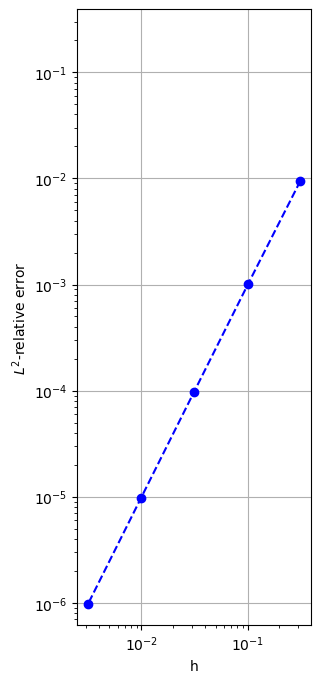

In [16]:
# Allocation for error values
nvec = np.int_(np.logspace(1, 3, 5))
error = np.zeros(len(nvec), dtype=complex)

# Compute FEM solutions and errors for different mesh sizes
for j, n in enumerate(nvec):
    gfu, mesh, V = compute_fem(L, k, distributed_load, uD, n)

    # Compute exact solution (interpolated in the functional space V)
    u_exact = GridFunction(V)
    u_exact.Set((cos(k * (x - np.pi / 2)) / cos(k * np.pi / 2) - 1) / k**2)

    # Compute L^2 relative error
    error[j] = sqrt(Integrate((gfu-u_exact)*(gfu-u_exact), mesh))/sqrt(Integrate(u_exact*u_exact, mesh))

plt.figure(figsize=(10, 8))
plt.loglog(L / nvec, error.real, 'bo--')
plt.xlabel('h')
plt.ylabel(r'$L^2$-relative error')
plt.axis("square")
plt.grid()
plt.show()

### Interactive solver

We can make an interactive solver, where you can change the number of cells via a slider and see how the solution changes.
You need to run this notebook in a Jupyter session to see and use the slider.

In [ ]:
from ipywidgets import widgets
from ipywidgets import interact

# Exact solution on a fine grid
x_grid = np.linspace(0., L, 100)
u_exact = (np.cos(k * (x_grid - np.pi / 2)) / np.cos(k * np.pi / 2) - 1) / k**2

@interact(num_cells=widgets.IntSlider(min=1, max=20, value=5, description='number of cells'))
def plot(num_cells=5):
    plt.xlabel(r'$x$')
    plt.ylabel(r'$\Re(u)$')
    plt.title('Finite element solution for the Helmholtz equation')

    # Compute the FEM solution for the given number of cells
    gfu, mesh, V = compute_fem(L, k, distributed_load, uD, num_cells)

    # Approximated solution
    x_mesh = np.array([v.point[0] for v in mesh.vertices])
    u_h = np.array([gfu(mesh(v.point[0])) for v in mesh.vertices])

    # Plotting both the numerical and exact solutions
    plt.plot(x_grid, u_exact.real, 'k', label='Exact')
    plt.plot(x_mesh, u_h.real, 'o--', label='Approx.: ' + str(num_cells) + ' cells')
    plt.legend(loc='upper left')

### Exercise
Re-implement the FEM function ``compute_fem`` modifying the type of finite elements: use 2nd, 3rd, 4th and 5th-order piecewise continuous Lagrange polynomials to approximate the Helmholtz solution. Which is the effect of this selection on the order of convergence of the method? Please, illustrate your answer with a plot of the error as a function of the mesh size $h$ for each type of finite element. 

In [18]:
## YOUR CODE HERE